Configuration:
  Stocks: AAPL, GOOGL, MSFT, AMZN, TSLA
  Date Range: 2020-01-01 to 2024-12-31

Task 1: Downloading stock data...
  AAPL: 1257 records
  GOOGL: 1257 records
  MSFT: 1257 records
  AMZN: 1257 records
  TSLA: 1257 records
Downloaded: 5/5 stocks

Task 2: Cleaning data...
Cleaned: 5 stocks

Task 3: Computing logarithmic returns...
  AAPL: mean=0.000989, std=0.019947
  GOOGL: mean=0.000821, std=0.020494
  MSFT: mean=0.000810, std=0.019234
  AMZN: mean=0.000674, std=0.022659
  TSLA: mean=0.002132, std=0.042211

Task 4: Aligning timestamps and combining stocks...
  Unique trading dates: 1257
  Combined shape: (6285, 9)
  Date range: 2020-01-02 00:00:00-05:00 to 2024-12-30 00:00:00-05:00

Saving processed data...
  Combined: data/processed/combined_stock_data.csv (6285 rows)
  AAPL: data/processed/AAPL_cleaned.csv (1257 rows)
  GOOGL: data/processed/GOOGL_cleaned.csv (1257 rows)
  MSFT: data/processed/MSFT_cleaned.csv (1257 rows)
  AMZN: data/processed/AMZN_cleaned.csv (1257 row

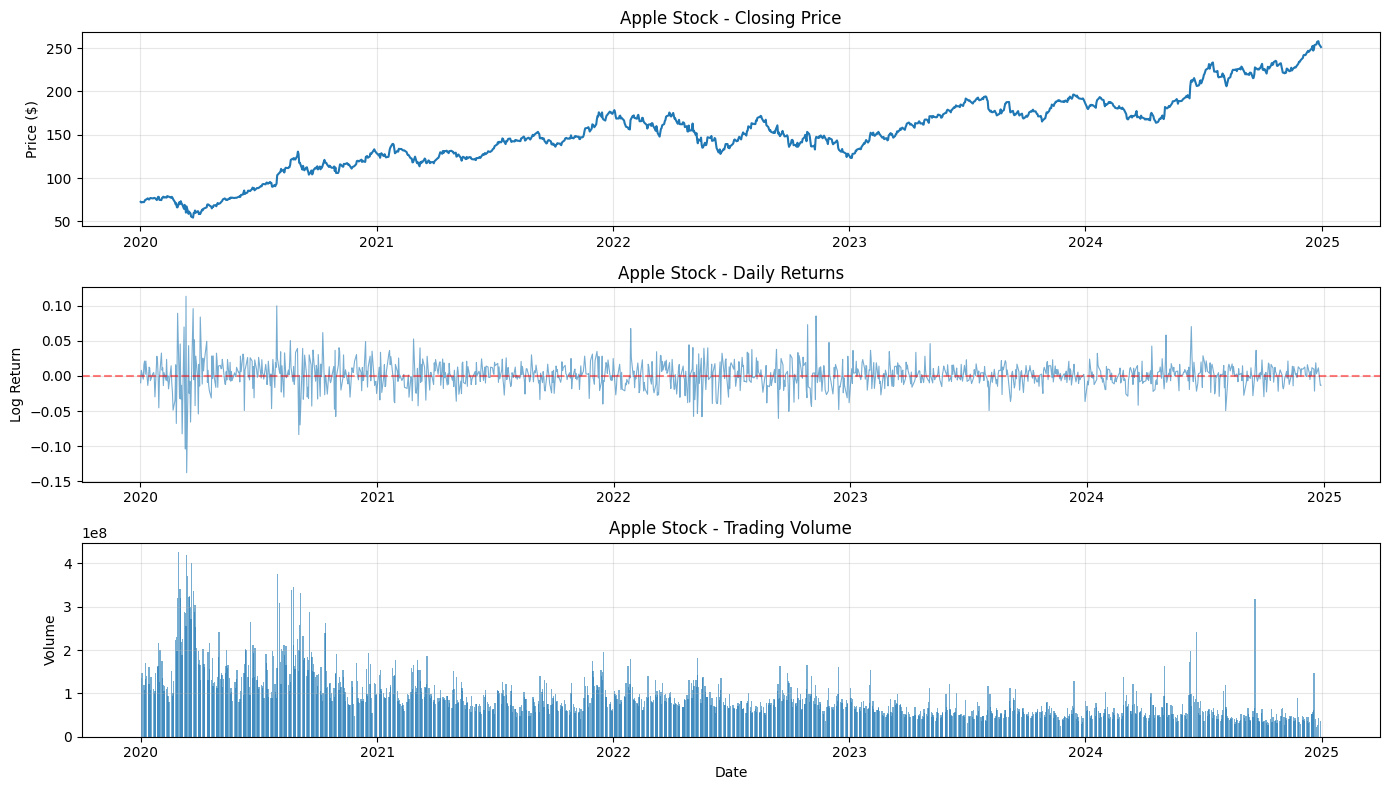

Data quality validation:
  Missing values: 0
  Return mean: 0.001072
  Return std: 0.026385
  Output files verified: True

Data Preprocessing Complete
Processed 5 stocks with 6285 total records
Date range: 2020-01-01 to 2024-12-31
Output directory: data/processed/


In [1]:
"""
Stock Market Data Preprocessing
Ngoc Vo - Data Preprocessing Module
Project: Stock Market Return Prediction

Tasks:
1. Collect daily OHLCV data for multiple stocks
2. Clean data (handle missing values, adjust for splits/dividends)
3. Compute next-day logarithmic returns
4. Combine multiple stocks into aligned dataset
"""

# Import required libraries
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import warnings
import os

warnings.filterwarnings('ignore')

# =============================================================================
# Configuration
# =============================================================================

STOCK_LIST = ['AAPL', 'GOOGL', 'MSFT', 'AMZN', 'TSLA']
START_DATE = '2020-01-01'
END_DATE = '2024-12-31'

print("Configuration:")
print(f"  Stocks: {', '.join(STOCK_LIST)}")
print(f"  Date Range: {START_DATE} to {END_DATE}\n")

# =============================================================================
# Task 1: Collect Daily OHLCV Data
# =============================================================================

print("Task 1: Downloading stock data...")

raw_data = {}

for symbol in STOCK_LIST:
    try:
        ticker = yf.Ticker(symbol)
        data = ticker.history(start=START_DATE, end=END_DATE)
        
        if not data.empty:
            raw_data[symbol] = data
            print(f"  {symbol}: {len(data)} records")
    except Exception as e:
        print(f"  {symbol}: Error - {e}")

print(f"Downloaded: {len(raw_data)}/{len(STOCK_LIST)} stocks\n")

# =============================================================================
# Task 2: Clean Data
# =============================================================================

print("Task 2: Cleaning data...")

cleaned_data = {}

for symbol, data in raw_data.items():
    df = data.copy()
    
    # Keep OHLCV columns only
    df = df[['Open', 'High', 'Low', 'Close', 'Volume']]
    df.columns = ['open', 'high', 'low', 'close', 'volume']
    
    # Handle missing values
    missing_count = df.isnull().sum().sum()
    if missing_count > 0:
        df = df.fillna(method='ffill').fillna(method='bfill')
        print(f"  {symbol}: Filled {missing_count} missing values")
    
    # Add symbol identifier
    df['symbol'] = symbol
    
    cleaned_data[symbol] = df

print(f"Cleaned: {len(cleaned_data)} stocks\n")

# =============================================================================
# Task 3: Compute Logarithmic Returns
# =============================================================================

print("Task 3: Computing logarithmic returns...")

data_with_returns = {}

for symbol, data in cleaned_data.items():
    df = data.copy()
    
    # Calculate log return: log(P_t / P_{t-1})
    df['log_return'] = np.log(df['close'] / df['close'].shift(1))
    
    # Target variable: next-day return
    df['next_day_return'] = df['log_return'].shift(-1)
    
    data_with_returns[symbol] = df
    
    returns = df['next_day_return'].dropna()
    print(f"  {symbol}: mean={returns.mean():.6f}, std={returns.std():.6f}")

print()

# =============================================================================
# Task 4: Align Timestamps and Combine
# =============================================================================

print("Task 4: Aligning timestamps and combining stocks...")

# Collect all unique dates
all_dates = set()
for df in data_with_returns.values():
    all_dates.update(df.index)
all_dates = sorted(all_dates)

print(f"  Unique trading dates: {len(all_dates)}")

# Align all stocks to common dates
aligned_data = {}
for symbol, data in data_with_returns.items():
    df = data.reindex(all_dates)
    df = df.fillna(method='ffill')
    df['symbol'] = symbol
    aligned_data[symbol] = df

# Combine into single dataset
combined_data = pd.concat(aligned_data.values(), axis=0)
combined_data = combined_data.reset_index()

# Handle index column name
if 'index' in combined_data.columns:
    combined_data = combined_data.rename(columns={'index': 'date'})
elif 'Date' in combined_data.columns:
    combined_data = combined_data.rename(columns={'Date': 'date'})

combined_data = combined_data.sort_values(['date', 'symbol']).reset_index(drop=True)

print(f"  Combined shape: {combined_data.shape}")
print(f"  Date range: {combined_data['date'].min()} to {combined_data['date'].max()}\n")

# =============================================================================
# Save Processed Data
# =============================================================================

print("Saving processed data...")

os.makedirs('data/processed', exist_ok=True)

# Save combined dataset
combined_path = 'data/processed/combined_stock_data.csv'
combined_data.to_csv(combined_path, index=False)
print(f"  Combined: {combined_path} ({len(combined_data)} rows)")

# Save individual stock files
for symbol in STOCK_LIST:
    stock_df = combined_data[combined_data['symbol'] == symbol]
    stock_path = f'data/processed/{symbol}_cleaned.csv'
    stock_df.to_csv(stock_path, index=False)
    print(f"  {symbol}: {stock_path} ({len(stock_df)} rows)")

print()

# =============================================================================
# Create Visualization
# =============================================================================

print("Creating visualization...")

if 'AAPL' in data_with_returns:
    apple_data = data_with_returns['AAPL']
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 8))
    
    # Price chart
    axes[0].plot(apple_data.index, apple_data['close'], linewidth=1.5)
    axes[0].set_title('Apple Stock - Closing Price', fontsize=12)
    axes[0].set_ylabel('Price ($)')
    axes[0].grid(True, alpha=0.3)
    
    # Returns chart
    axes[1].plot(apple_data.index, apple_data['next_day_return'], 
                 alpha=0.6, linewidth=0.8)
    axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
    axes[1].set_title('Apple Stock - Daily Returns', fontsize=12)
    axes[1].set_ylabel('Log Return')
    axes[1].grid(True, alpha=0.3)
    
    # Volume chart
    axes[2].bar(apple_data.index, apple_data['volume'], 
                alpha=0.6, width=2)
    axes[2].set_title('Apple Stock - Trading Volume', fontsize=12)
    axes[2].set_ylabel('Volume')
    axes[2].set_xlabel('Date')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    viz_path = 'data/processed/stock_visualization.png'
    plt.savefig(viz_path, dpi=300, bbox_inches='tight')
    print(f"  Visualization: {viz_path}\n")
    plt.show()

# =============================================================================
# Data Quality Validation
# =============================================================================

print("Data quality validation:")

# Check missing values
missing = combined_data[['open', 'high', 'low', 'close', 'volume']].isnull().sum().sum()
print(f"  Missing values: {missing}")

# Check return statistics
all_returns = combined_data['next_day_return'].dropna()
print(f"  Return mean: {all_returns.mean():.6f}")
print(f"  Return std: {all_returns.std():.6f}")

# Verify output files
files_exist = all([
    os.path.exists('data/processed/combined_stock_data.csv'),
    os.path.exists('data/processed/AAPL_cleaned.csv'),
])
print(f"  Output files verified: {files_exist}\n")

# =============================================================================
# Summary
# =============================================================================

print("="*70)
print("Data Preprocessing Complete")
print("="*70)
print(f"Processed {len(STOCK_LIST)} stocks with {len(combined_data)} total records")
print(f"Date range: {START_DATE} to {END_DATE}")
print(f"Output directory: data/processed/")
print("="*70)